In [1]:
using Random
using PyPlot
using Statistics
using OrdinaryDiffEq
using LinearAlgebra
using DifferentialEquations


include("SuperradiantLasing/SuperradiantLasing.jl")
using .SuperradiantLasing

for n in names(SuperradiantLasing, all=true)
    @eval import .SuperradiantLasing: $(n)
end

include("SteadyState.jl")
using .SteadyState
include("MixingApproximations.jl")

function simulate_coherence_correlator_from_samples_LHS(
    S_samples::AbstractVector{Int},
    M_samples::AbstractVector{Int},
    model::CoherenceModel;
    τ_max::Float64,
    n_grid::Int = 1000,
    rng::AbstractRNG = Random.default_rng(),
)
    @assert length(S_samples) == length(M_samples)

    τ_grid = collect(range(0.0, τ_max, length = n_grid))
    Cτ = zeros(Float64, n_grid)

    for n in eachindex(S_samples)
        S0 = S_samples[n]
        M0 = M_samples[n]

        Cτ .+= simulate_coherence_sector(
            model,
            S0,
            M0,
            τ_grid;
            w_in = sqrt(A_JM_minus2(S0, M0)),
            rng = rng,
        )
    end

    Cτ ./= length(S_samples)
    return τ_grid, Cτ
end

function simulate_coherence_correlator_from_samples_RHS(
    S_samples::AbstractVector{Int},
    M_samples::AbstractVector{Int},
    model::CoherenceModel;
    τ_max::Float64,
    n_grid::Int = 1000,
    rng::AbstractRNG = Random.default_rng(),
)
    @assert length(S_samples) == length(M_samples)

    τ_grid = collect(range(0.0, τ_max, length = n_grid))
    Cτ = zeros(Float64, n_grid)

    for n in eachindex(S_samples)
        S_pop = S_samples[n]
        M_pop = M_samples[n]

        S0 = S_pop
        M0 = M_pop + 1

        Cτ .+= simulate_coherence_sector(
            model,
            S0,
            M0,
            τ_grid;
            w_in = sqrt(A_JM_minus2(S0, M0)),
            rng = rng,
        )
    end

    Cτ ./= length(S_samples)
    return τ_grid, Cτ
end

simulate_coherence_correlator_from_samples_RHS (generic function with 1 method)

In [208]:
include("PlotSetup.jl")

@R_str (macro with 1 method)

In [2]:
function observable_grid_from_single_trajectory(
    model::PopulationModel,
    observable;
    t_max::Float64,
    n_grid::Int = 2000,
    S0::Int = model.Jmax,
    M0::Int = model.Jmax,
    rng::AbstractRNG = Random.default_rng(),
)
    time_grid = collect(range(0.0, t_max, length = n_grid))

    v0 = observable(S0, M0, model)
    vals = Vector{typeof(v0)}(undef, n_grid)

    st = PopState(S0, M0, 0.0)
    buf = EventBuffer()

    i = 1
    while i <= n_grid
        val = observable(st.S, st.M, model)

        ok = gillespie_step!(rng, st, buf, model)

        if !ok
            vals[i:end] .= val
            break
        end

        while i <= n_grid && time_grid[i] < st.t
            vals[i] = val
            i += 1
        end
    end

    return time_grid, vals
end

function continue_ensemble!(
    states::Vector{PopState},
    model::PopulationModel,
    observable;
    Δt::Float64,
    rng::AbstractRNG = Random.default_rng(),
)
    vals = Vector{Float64}(undef, length(states))

    for n in eachindex(states)
        st = states[n]
        buf = EventBuffer()

        t_end = st.t + Δt

        while st.t < t_end
            ok = gillespie_step!(rng, st, buf, model)
            if !ok
                break
            end
        end

        vals[n] = observable(st.S, st.M, model)
    end

    return vals
end

function estimate_steady_state_time(
    model::PopulationModel,
    observable;
    N_traj::Int,
    S0::Int = model.Jmax,
    M0::Int = model.Jmax,
    Δt::Float64 = 1.0,
    reltol::Float64 = 0.02,
    n_confirm::Int = 5,
    max_iter::Int = 10_000,
    rng::AbstractRNG = Random.default_rng(),
)
    states = [PopState(S0, M0, 0.0) for _ in 1:N_traj]

    means = Float64[]
    t_ss = NaN

    for iter in 1:max_iter
        vals = continue_ensemble!(
            states,
            model,
            observable;
            Δt = Δt,
            rng = rng,
        )

        t = states[1].t
        push!(means, mean(vals))

        if length(means) >= 2n_confirm
            old = mean(means[end-2n_confirm+1:end-n_confirm])
            new = mean(means[end-n_confirm+1:end])

            if abs(new - old) < reltol * max(abs(new), eps())
                t_ss = t
                return t_ss, means, states
            end
        end
    end

    println(means)
    return t_ss, means, states
end

function trapezoid_until_index(y, x, i_max)
    s = 0.0
    @inbounds for i in 1:i_max-1
        s += 0.5 * (y[i] + y[i+1]) * (x[i+1] - x[i])
    end
    return s
end

function qs_integral(τ_grid, Cτ, stats, t_mix)
    i_mix = searchsortedlast(τ_grid, t_mix)

    I_exact = trapezoid_until_index(Cτ, τ_grid, i_mix)

    I_tail =
        stats.λ_qs > 0.0 ?
        stats.survival_fraction * stats.mean_amp_mix / stats.λ_qs :
        Inf

    return I_exact + I_tail
end

function trapezoid(y, x)
    s = 0.0
    @inbounds for i in 1:length(x)-1
        s += 0.5 * (y[i] + y[i+1]) * (x[i+1] - x[i])
    end
    return s
end

function build_basis_naive(N::Int, S_samples, M_samples, pad::Int)
    S_abs_min = 0
    S_abs_max = N ÷ 2

    Smin = clamp(minimum(S_samples) - pad, S_abs_min, S_abs_max)
    Smax = clamp(maximum(S_samples) + pad, S_abs_min, S_abs_max)

    Mmin = minimum(M_samples) - pad
    Mmax = maximum(M_samples) + pad

    return [
        (S, M)
        for S in Smin:Smax
        for M in max(-S, Mmin):min(S, Mmax)
    ]
end

Δt_N(N) = 5.0 * 0.005 * 0.03 * (30000 / N) ^ 0.75

Δt_N (generic function with 1 method)

In [12]:
using StatsBase

function sample_population_basis(
    rng::AbstractRNG,
    basis,
    p::AbstractVector{<:Real},
    n_samples::Int,
)
    @assert length(basis) == length(p)
    @assert all(p .>= 0)
    @assert sum(p) > 0

    inds = sample(
        rng,
        eachindex(basis),
        Weights(p),
        n_samples;
        replace = true,
    )

    S_samples = Vector{Int}(undef, n_samples)
    M_samples = Vector{Int}(undef, n_samples)

    @inbounds for k in 1:n_samples
        S, M = basis[inds[k]]
        S_samples[k] = S
        M_samples[k] = M
    end

    return S_samples, M_samples, inds
end

sample_population_basis (generic function with 1 method)

In [ ]:
using DataStructures
using SparseArrays

function build_coherence_basis_naive(N::Int, S_samples, M_samples, pad::Int)
    Jmax = N ÷ 2

    Smin = clamp(minimum(S_samples) - pad, 0, Jmax)
    Smax = clamp(maximum(S_samples) + pad, 0, Jmax)

    Mmin = minimum(M_samples) - pad
    Mmax = maximum(M_samples) + pad

    basis = Tuple{Int,Int}[]

    for S in Smin:Smax
        # coherence state (S,M) means |S,M-1><S,M|,
        # so both M and M-1 must lie in [-S,S].
        lo = max(-S + 1, Mmin)
        hi = min( S,     Mmax)

        for M in lo:hi
            if valid_coherence_state(S, M, Jmax)
                push!(basis, (S, M))
            end
        end
    end

    return basis
end

function set_up_coherence_rate_matrix_on_basis(
    basis,
    params,
    Jmax;
    close_boundary::Bool = false,
)
    index_mapping = Dict(basis .=> eachindex(basis))

    sparse_constructor = DefaultDict{Tuple{Int,Int}, Float64}(0.0)
    leakage = zeros(Float64, length(basis))

    for state in basis
        i = index_mapping[state]

        internal, sink_rate = outgoing_for_coherence_state(state, params, Jmax)

        # The full outgoing decay of this coherence component.
        out_rate = sum(values(internal)) + sink_rate

        sparse_constructor[(i, i)] -= out_rate

        for (target, rate) in internal
            if haskey(index_mapping, target)
                j = index_mapping[target]
                sparse_constructor[(j, i)] += rate
            else
                leakage[i] += rate

                if close_boundary
                    # For coherence sectors I would usually NOT use this.
                    # But this option keeps the restricted norm from losing
                    # internal transfer probability/amplitude at the edge.
                    sparse_constructor[(i, i)] += rate
                end
            end
        end
    end

    I = Int[]
    J = Int[]
    V = Float64[]

    sizehint!(I, length(sparse_constructor))
    sizehint!(J, length(sparse_constructor))
    sizehint!(V, length(sparse_constructor))

    for ((i, j), v) in sparse_constructor
        push!(I, i)
        push!(J, j)
        push!(V, v)
    end

    n = length(basis)
    R = sparse(I, J, V, n, n)
    dropzeros!(R)

    return basis, index_mapping, R, leakage
end

function spectrum_from_coherence_generator(Rc, c0, readout, ωs)
    n = size(Rc, 1)
    Isp = spdiagm(0 => ones(ComplexF64, n))

    c0c = ComplexF64.(c0)
    vc = ComplexF64.(readout)

    Sω = similar(ωs, Float64)

    for (k, ω) in pairs(ωs)
        @show k
        A = ComplexF64.(Rc) + im * ω * Isp
        x = A \ c0c
        Sω[k] = -2 * real(dot(vc, x))
    end

    return Sω
end
function spectrum_sparse_lu(Rc, c0, readout, ωs)
    n = size(Rc, 1)

    Rc_c = ComplexF64.(Rc)
    c0c = ComplexF64.(c0)
    v = ComplexF64.(readout)
    Isp = spdiagm(0 => ones(ComplexF64, n))

    Sω = zeros(Float64, length(ωs))

    for (k, ω) in pairs(ωs)
        @show k
        Aω = Rc_c + im * ω * Isp
        F = lu(Aω)

        x = F \ c0c
        Sω[k] = -2 * real(sum(v .* x))
    end

    return Sω
end

function integrated_correlators_from_population(
    pop_basis,
    p_ss,
    coh_idx,
    F,
)
    I_LHS = 0.0
    I_RHS = 0.0

    @inbounds for i in eachindex(pop_basis)
        S, M = pop_basis[i]
        p = p_ss[i]

        state_L = (S, M)
        if haskey(coh_idx, state_L)
            I_LHS += p * sqrt(A_JM_minus2(S, M)) * F[coh_idx[state_L]]
        end

        state_R = (S, M + 1)
        if haskey(coh_idx, state_R)
            I_RHS += p * sqrt(A_JM_minus2(S, M + 1)) * F[coh_idx[state_R]]
        end
    end

    return I_LHS, I_RHS, I_LHS - I_RHS
end

spectrum_sparse_lu (generic function with 1 method)

In [118]:
function resolvent_pole_estimates(
    R,
    readout::AbstractVector,
    source::AbstractVector;
    depth::Int = 4,
)
    @assert depth >= 2
    @assert size(R, 1) == size(R, 2)
    @assert length(readout) == size(R, 1)
    @assert length(source) == size(R, 1)

    # Factorize once. We need repeated solves with R'.
    Ffac = factorize(R')

    # Factorial-normalized moment vectors:
    #
    #   F₀ = ∫₀∞ exp(R t)' readout dt = -R'^{-1} readout
    #   Fₙ₊₁ = -R'^{-1} Fₙ
    #
    # Then Jₙ = source ⋅ Fₙ = ∫₀∞ tⁿ/n! G(t) dt.
    Fvecs = Vector{Vector{eltype(readout)}}(undef, depth)

    Fvecs[1] = -(Ffac \ readout)

    for n in 2:depth
        Fvecs[n] = -(Ffac \ Fvecs[n - 1])
    end

    J = Vector{promote_type(eltype(readout), eltype(source))}(undef, depth)

    for n in 1:depth
        J[n] = dot(source, Fvecs[n])
    end

    # For a single pole G(t) = A exp(λt),
    #
    #   Jₙ = -A / λⁿ⁺¹
    #
    # hence λ = -Jₙ / Jₙ₊₁.
    λ_est = Vector{eltype(J)}(undef, depth - 1)

    for n in 1:depth-1
        λ_est[n] = -J[n] / J[n + 1]
    end

    linewidth_est = -real.(λ_est)
    frequency_est = imag.(λ_est)

    return (
        moments = J,
        moment_vectors = Fvecs,
        λ_est = λ_est,
        linewidth_est = linewidth_est,
        frequency_est = frequency_est,
    )
end

function lhs_source_vector(pop_basis, p_ss, coh_idx, ncoh)
    b = zeros(Float64, ncoh)

    @inbounds for i in eachindex(pop_basis)
        S, M = pop_basis[i]
        state = (S, M)

        if haskey(coh_idx, state)
            b[coh_idx[state]] += p_ss[i] * sqrt(A_JM_minus2(S, M))
        end
    end

    return b
end

lhs_source_vector (generic function with 1 method)

In [155]:
using PyPlot

# ----------------------------
# Parameters
# ----------------------------
Base.@kwdef struct BadCavityParams
    N::Int
    g::Float64          # single-atom cavity coupling (paper's Ω)
    kappa::Float64      # cavity linewidth (paper's κ)
    gamma::Float64      # spontaneous decay rate (paper's γ)
    w::Float64          # repump rate
    gamma_phi::Float64  # pure dephasing rate, replacing 1/T2
    Delta::Float64 = 0.0  # cavity-atom detuning Δ = ωc - ωa
end

# ----------------------------
# Mean-field / cumulant EOM
#
# State vector:
# u = [z, Re(p), Im(p), c, n]
#
# z = <σ^z>
# p = <a† σ^->
# c = <σ1^+ σ2^->
# n = <a† a>
#
# Uses the paper's Eq. (2)-(5), with 1/T2 -> gamma_phi,
# and neglects the third-order cumulant in Eq. (3),
# exactly as stated there.
# ----------------------------
function badcavity_rhs!(du, u, pars::BadCavityParams, t)
    z, px, py, c, n = u
    p = px + 1im * py

    N  = pars.N
    g  = pars.g
    κ  = pars.kappa
    γ  = pars.gamma
    w  = pars.w
    γϕ = pars.gamma_phi
    Δ  = pars.Delta

    d0 = (w - γ) / (w + γ)

    # Eq. (2)
    dz = -(w + γ) * (z - d0) + 1im * g * (p - conj(p))

    # Eq. (3), third-order cumulant dropped
    #dp = -((w + γ)/2 + γϕ + κ/2 - 1im * Δ) * p +
    #     1im * g/2 * (n * z + z/2 + (N - 1) * c)
    dp = -((w + γ)/2 + γϕ + κ/2 - 1im * Δ) * p +
     1im * g/2 * (n * z + (z + 1)/2 + (N - 1) * c)

    # Eq. (4)
    dc = -(w + γ + 2γϕ) * c + (g * z / (2im)) * (p - conj(p))

    # Eq. (5)
    dn = -κ * n + (N * g / (2im)) * (p - conj(p))

    du[1] = real(dz)
    du[2] = real(dp)
    du[3] = imag(dp)
    du[4] = real(dc)   # c stays real in the resonant case
    du[5] = real(dn)
    return nothing
end

# ----------------------------
# Integrate to steady state
# ----------------------------
function badcavity_steady_state(pars::BadCavityParams;
        u0 = [0.0, 0.0, 0.0, 0.0, 0.0],
        tmax = 10_000.0,
        reltol = 1e-10,
        abstol = 1e-12)

    prob = ODEProblem(badcavity_rhs!, u0, (0.0, tmax), pars)
    sol = solve(prob, Rodas5P(); reltol=reltol, abstol=abstol)

    u = sol.u[end]
    z, px, py, c, n = u
    p = px + 1im * py

    return (
        z = z,
        p = p,
        c = c,
        n = n,
        sol = sol,
    )
end

# ----------------------------
# Regression matrix for the spectrum
#
# q(t) = [ G(t), H(t) ]^T
# G(t) = <a†(t) a(0)>
# H(t) = <σ^+(t) a(0)>
#
# Following the paper's Eq. (9), but with pure dephasing γϕ
# instead of 1/T2, so the transverse decay is:
# Γperp = (w + γ)/2 + γϕ
#
# On resonance, the spectrum is Lorentzian in the paper's closure.
# Here we evaluate it directly from the resolvent, which is more robust.
# ----------------------------
function regression_matrix(pars::BadCavityParams, z_ss)
    N  = pars.N
    g  = pars.g
    κ  = pars.kappa
    γ  = pars.gamma
    w  = pars.w
    γϕ = pars.gamma_phi
    Δ  = pars.Delta

    Γperp = (w + γ)/2 + γϕ

    # q̇ = A q
    A = ComplexF64[
        -κ/2                    1im * N * g / 2
        -1im * g * z_ss / 2    -(Γperp + 1im * Δ)
    ]
    return A
end

# ----------------------------
# Spectrum from the Laplace/resolvent formula
#
# S(ω) = 2 Re ∫_0^∞ dt e^{i ω t} <a†(t) a(0)>
#
# For q̇ = A q and q(0) = q0:
# ∫_0^∞ dt e^{iω t} q(t) = -(A + iω I)^(-1) q0
# ----------------------------
function badcavity_spectrum(ωgrid, pars::BadCavityParams, ss)
    z_ss = ss.z
    n_ss = ss.n
    p_ss = ss.p

    A = regression_matrix(pars, z_ss)

    # Initial conditions from the steady state
    # G(0) = <a† a> = n_ss
    # H(0) = <σ^+ a> = conj(<a† σ^->) = conj(p_ss)
    q0 = ComplexF64[n_ss, conj(p_ss)]

    S = similar(ωgrid, Float64)
    I2 = Matrix{ComplexF64}(I, 2, 2)

    for (j, ω) in pairs(ωgrid)
        val = ((1im * ω * I2 - A) \ q0)
        S[j] = 2 * real(val[1])
    end

    return S
end

# ----------------------------
# Convenience wrapper
# ----------------------------
function steady_state_and_spectrum(ωgrid, pars::BadCavityParams;
        u0 = [0.0, 0.0, 0.0, 0.0, 0.0],
        tmax = 10_000.0)

    #@show pars.w / (pars.N * pars.g^2 / pars.kappa)

    ss = badcavity_steady_state(pars; u0=u0, tmax=tmax)
    Sω = badcavity_spectrum(ωgrid, pars, ss)
    return ss, Sω
end


function linewidth_from_regression_matrix(pars, ss)
    A = regression_matrix(pars, ss.z)
    vals = eigvals(A)
    λslow = vals[argmax(real.(vals))]
    Δω = -2 * real(λslow)
    Δν = Δω / (2π)
    return Δν
end

# --------------------------------
# linewidth scan for PRL Fig. 3(b)
# --------------------------------
function scan_w_linewidth_badcavity(
    ws;
    N::Int = 10^6,
    g::Float64 = 37.0,
    kappa::Float64 = 9.4e5,
    gamma::Float64 = 0.01,
    gamma_phi::Float64 = 1.0,   # use this as 1/T2
    Delta::Float64 = 0.0,
    nω::Int = 12001,
    ωmax_factor::Float64 = 20.0,
    tmax_ss::Float64 = 2.0e4,
    u0 = [0.0, 0.0, 0.0, 0.0, 0.0],
)
    widths = Float64[]
    nss = Float64[]
    zss = Float64[]
    pss = ComplexF64[]

    for w in ws
        #@show w
        pars = BadCavityParams(
            N = N,
            g = g,
            kappa = kappa,
            gamma = gamma,
            w = w,
            gamma_phi = gamma_phi,
            Delta = Delta,
        )

        # choose a frequency window that scales with the expected broadening
        # at large w the linewidth can become O(w), so use max(gamma_phi, w)
        ωmax = ωmax_factor * max(gamma_phi, gamma, w, g^2 * N / kappa / 100)
        ωgrid = range(-ωmax, ωmax, length=nω)

        ss, Sω = steady_state_and_spectrum(ωgrid, pars; u0=u0, tmax=tmax_ss)
        #Δν = spectrum_fwhm(collect(ωgrid), Sω)
        push!(widths, linewidth_from_regression_matrix(pars, ss))

        #push!(widths, Δν)
        push!(nss, ss.n)
        push!(zss, ss.z)
        push!(pss, ss.p)
    end

    return (
        ws = collect(ws),
        widths = widths,
        nss = nss,
        zss = zss,
        pss = pss,
        wmax = N * g^2 / kappa,
        gamma = gamma,
        gamma_phi = gamma_phi,
    )
end

# --------------------------------
# plotting helper for panel (b)
# --------------------------------
function plot_prl_fig3b_like(scan)
    figure(figsize=(5.2, 4.0))

    loglog(scan.ws, scan.widths, label = L"\Delta \nu")

    axvline(scan.gamma, color="k", linestyle="--", linewidth=1)
    axvline(scan.gamma_phi, color="k", linestyle="--", linewidth=1)
    axvline(scan.wmax, color="k", linestyle="--", linewidth=1)

    xlabel(L"w\ [\mathrm{s}^{-1}]")
    ylabel(L"\Delta \nu\ [\mathrm{s}^{-1}]")

    text(scan.gamma * 1.05, maximum(scan.widths) / 5, L"\gamma")
    text(scan.gamma_phi * 1.05, maximum(scan.widths) / 5, L"T_2^{-1}")
    text(scan.wmax * 1.05, maximum(scan.widths) / 5, L"w_{\max}")

    grid(true, which="both", alpha=0.3)
    tight_layout()
end

# --------------------------------
# reasonable defaults for arbitrary N
# reuses:
#   scan_w_linewidth_badcavity
#   plot_prl_fig3b_like
# --------------------------------
function plot_linewidth_cut_for_N(
    N::Int;
    g::Float64 = 37.0,
    kappa::Float64 = 9.4e5,
    gamma::Float64 = 0.01,
    gamma_phi::Float64 = 1.0,   # interpreted as 1/T2 in your code
    Delta::Float64 = 0.0,
    ws = nothing,
    npts::Int = 120,
    nω::Int = 12001,
    ωmax_factor::Float64 = 20.0,
    tmax_ss::Float64 = 2.0e4,
    u0 = [0.0, 0.0, 0.0, 0.0, 0.0],
)
    wmax = N * g^2 / kappa

    if ws === nothing
        scales = [gamma, gamma_phi, wmax]
        positive_scales = [x for x in scales if x > 0]
        wmin = min(minimum(positive_scales) / 10, 1e-3)
        wmax_plot = max(maximum(positive_scales) * 100, 1e2)
        ws = 10.0 .^ range(log10(wmin), log10(wmax_plot), length=npts)
    end

    @show g^2 / kappa

    scan = scan_w_linewidth_badcavity(
        ws;
        N = N,
        g = g,
        kappa = kappa,
        gamma = gamma,
        gamma_phi = gamma_phi,
        Delta = Delta,
        nω = nω,
        ωmax_factor = ωmax_factor,
        tmax_ss = tmax_ss,
        u0 = u0,
    )

    plot_prl_fig3b_like(scan)
    title("N = $(N)")

    return scan
end

plot_linewidth_cut_for_N (generic function with 1 method)

In [ ]:
rng = Xoshiro(1234)
res = []

N = 10000
for rbar in exp.(range(log(0.01), log(1.5), length = 80))
    Jmax = N ÷ 2

    g = 37.0
    κ = 9.4e5
    Γ = g^2 / κ
    r = rbar * N * Γ
    γ = 0.05 * N * Γ

    pop_model = PopulationModel(N, Jmax, Γ, 0.0, γ, r, 0.0)
    obsI(S, M, model) = S*(S+1) - M*(M-1)

    t_ss, τ_auto = estimate_steady_state_time(pop_model, obsI; N_traj = 100, Δt = Δt_N(N) / Γ, reltol = 1e-2)
    S_samples_raw, M_samples_raw = get_stationary_population_samples_ergodic(pop_model,20_000;t_ss = t_ss,t_sample = 3t_ss,rng = rng)

    params = Dict(
        "global_decay" => pop_model.global_decay,
        "global_pump" => pop_model.global_pump,
        "local_pump" => pop_model.local_pump,
        "local_decay" => pop_model.local_decay,
        "local_dephasing" => pop_model.local_dephasing,
    )

    Ω = build_basis_naive(N, S_samples_raw, M_samples_raw, 200)
    basisΩ, idxΩ, RΩ, leakage = set_up_rate_matrix_on_basis(Ω, params, pop_model.Jmax; close_boundary = true)
    p0 = population_from_samples(basisΩ, idxΩ, S_samples_raw, M_samples_raw)
    p_ss = steady_by_implicit_euler(RΩ, p0; dt=1e3/Γ, nsteps=5)

    basisΩc, idxΩc, Rcoh, leakage_c = set_up_coherence_rate_matrix_on_basis(basisΩ, params, pop_model.Jmax; close_boundary = true)
    readout = [sqrt(A_JM_minus2(S, M)) for (S, M) in basisΩc]
    F = -(Rcoh' \ readout)
    I_LHS, I_RHS, I_comm = integrated_correlators_from_population(basisΩ, p_ss, idxΩc, F)
    G0 = mean(obsI.(S_samples_raw, M_samples_raw, Ref(pop_model)))
    @show N I_LHS/N^2, I_RHS/N^2, I_comm/N, G0/N^2, G0/I_LHS

    source_lhs = lhs_source_vector(basisΩ, p_ss, idxΩc, length(basisΩc))
    est = resolvent_pole_estimates(Rcoh, readout, source_lhs; depth = 6)
    readout = [coherence_readout(S, M) for (S, M) in basisΩc]
    source_lhs = lhs_source_vector(basisΩ, p_ss, idxΩc, length(basisΩc))
    push!(res, est.linewidth_est[end] )
end

N = 10000
(I_LHS / N ^ 2, I_RHS / N ^ 2, I_comm / N, G0 / N ^ 2, G0 / I_LHS) = (1.610005913796633e-7, 1.2759611003874724e-5, -0.12598610412495062, 1.5838280000000001e-6, 9.837404859371594)
N = 10000
(I_LHS / N ^ 2, I_RHS / N ^ 2, I_comm / N, G0 / N ^ 2, G0 / I_LHS) = (1.7837101119294634e-7, 1.2736572872973829e-5, -0.12558201861780882, 2.9500240000000004e-6, 16.538696396181326)
N = 10000
(I_LHS / N ^ 2, I_RHS / N ^ 2, I_comm / N, G0 / N ^ 2, G0 / I_LHS) = (1.981059272699192e-7, 1.271176696609649e-5, -0.1251366103882657, 1.579434e-6, 7.972674123212992)
N = 10000
(I_LHS / N ^ 2, I_RHS / N ^ 2, I_comm / N, G0 / N ^ 2, G0 / I_LHS) = (2.2060644027249676e-7, 1.2685051903669788e-5, -0.12464445463397289, 1.739762e-6, 7.886270218815992)
N = 10000
(I_LHS / N ^ 2, I_RHS / N ^ 2, I_comm / N, G0 / N ^ 2, G0 / I_LHS) = (2.4635613909409013e-7, 1.265627668177345e-5, -0.1240992054267936, 2.150069e-6, 8.727482935502696)
N = 10000
(I_LHS / N ^ 2, I_RHS / N ^ 2, I_comm / N, G0 / N ^ 2, G0 / I_LHS) = (2.759

In [156]:
scan_cum = scan_w_linewidth_badcavity(
    rs .* N .* Γ;
    N = N,
    g = g,
    kappa = kappa,
    gamma = 0.05 * N * Γ,
    gamma_phi = 0.0,
    Delta = 0.0,
    tmax_ss = 2.0e4,
)

(ws = [0.14563829787234048, 0.15517474969193779, 0.16533565204848957, 0.17616189420358672, 0.1876970428634131, 0.19998751749884744, 0.21308277714559498, 0.22703551943606146, 0.2419018926639131, 0.2577417217347043  …  12.344051439012693, 13.152344680052646, 14.013565273731944, 14.931178923479964, 15.908878268321024, 16.95059774270453, 18.060529409362506, 19.243139828908728, 20.50318803406573, 21.845744680851062], widths = [1.684468378500646, 1.644288527111119, 1.6024575499559266, 1.5589623312512366, 1.5137959662953553, 1.4669583583298844, 1.418456804996861, 1.368306565028373, 1.3165313951709539, 1.2631640469358678  …  0.043788241873142716, 0.1416165262976332, 0.2612110279177631, 0.39253662544282597, 0.534784340101056, 0.6881970889295244, 0.853279334071792, 1.0306500976260242, 1.2210039324598727, 1.4250990957026295], nss = [2.131889887968083e-7, 2.3269837544117636e-7, 2.544066349618358e-7, 2.7862671858399174e-7, 3.0572732512523605e-7, 3.3614512056453325e-7, 3.704002138962202e-7, 4.091159

In [210]:
rs =  exp.(range(log(0.01), log(1.5), length = 80))
figure(figsize=latex_plot_setup(ratio = 1.0, scale = 1.0))
loglog(scan_cum.ws, π*scan_cum.widths / Γ / 2, marker="v", label="cumulants")
scatter(rs * N * Γ, res / Γ, color = "red", label = "exact")

axvline(scan_cum.gamma, color="k", linestyle="--", linewidth=1)
axvline(scan_cum.gamma_phi, color="k", linestyle="--", linewidth=1)
axvline(scan_cum.wmax, color="k", linestyle="--", linewidth=1)
axhline(1.0)

xlabel(L"w\ [\mathrm{s}^{-1}]")
ylabel(L"\Delta \nu\ [\mathrm{s}^{-1}]")
grid(true, which="both", alpha=0.3)
legend()
tight_layout()
title(L"N=10000")
savefig("exact_vs_cumulants.pdf", bbox_inches = "tight")

LoadError: MethodError: no method matching /(::@NamedTuple{…}, ::Float64)
The function `/` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  /([91m::BigFloat[39m, ::Union{Float16, Float32, Float64})
[0m[90m   @[39m [90mBase[39m [90m[4mmpfr.jl:651[24m[39m
[0m  /([91m::VectorInterface.Zero[39m, ::Number)
[0m[90m   @[39m [36mVectorInterface[39m [90m~/.julia/packages/VectorInterface/J6qCR/src/[39m[90m[4monezero.jl:51[24m[39m
[0m  /([91m::VectorInterface.One[39m, ::Number)
[0m[90m   @[39m [36mVectorInterface[39m [90m~/.julia/packages/VectorInterface/J6qCR/src/[39m[90m[4monezero.jl:53[24m[39m
[0m  ...


In [205]:
function susceptibility_scan_for_N(
    N::Int;
    rng = Xoshiro(1234),
    rbars = exp.(range(log(0.01), log(1.5), length = 80)),
    g = 37.0,
    κ = 9.4e5,
    γbar = 0.05,
    basis_pad = 200,
    N_traj_ss = 100,
    N_samples = 20_000,
    reltol_ss = 1e-2,
    euler_dt_factor = 1e3,
    euler_nsteps = 5,
)
    Jmax = N ÷ 2
    Γ = g^2 / κ
    γ = γbar * N * Γ

    out = NamedTuple[]

    for rbar in rbars
        r = rbar * N * Γ

        pop_model = PopulationModel(N, Jmax, Γ, 0.0, γ, r, 0.0)

        obsI(S, M, model) = S * (S + 1) - M * (M - 1)

        t_ss, τ_auto = estimate_steady_state_time(
            pop_model,
            obsI;
            N_traj = N_traj_ss,
            Δt = Δt_N(N) / Γ,
            reltol = reltol_ss,
            rng = rng,
        )

        S_samples_raw, M_samples_raw = get_stationary_population_samples_ergodic(
            pop_model,
            N_samples;
            t_ss = t_ss,
            t_sample = 3t_ss,
            rng = rng,
        )

        params = Dict(
            "global_decay" => pop_model.global_decay,
            "global_pump" => pop_model.global_pump,
            "local_pump" => pop_model.local_pump,
            "local_decay" => pop_model.local_decay,
            "local_dephasing" => pop_model.local_dephasing,
        )

        # Population steady state on restricted basis
        Ω = build_basis_naive(N, S_samples_raw, M_samples_raw, basis_pad)

        basisΩ, idxΩ, RΩ, leakage = set_up_rate_matrix_on_basis(
            Ω,
            params,
            pop_model.Jmax;
            close_boundary = true,
        )

        p0 = population_from_samples(
            basisΩ,
            idxΩ,
            S_samples_raw,
            M_samples_raw,
        )

        p_ss = steady_by_implicit_euler(
            RΩ,
            p0;
            dt = euler_dt_factor / Γ,
            nsteps = euler_nsteps,
        )

        # Coherence resolvent on same restricted basis
        basisΩc, idxΩc, Rcoh, leakage_c = set_up_coherence_rate_matrix_on_basis(
            basisΩ,
            params,
            pop_model.Jmax;
            close_boundary = true,
        )

        readout = [sqrt(A_JM_minus2(S, M)) for (S, M) in basisΩc]

        F = -(Rcoh' \ readout)

        I_LHS, I_RHS, I_comm = integrated_correlators_from_population(
            basisΩ,
            p_ss,
            idxΩc,
            F,
        )

        G0 = mean(obsI.(S_samples_raw, M_samples_raw, Ref(pop_model)))
        linewidth_eff = G0 / I_LHS

        push!(out, (
            N = N,
            Γ = Γ,
            γ = γ,
            γbar = γbar,
            rbar = rbar,
            r = r,
            t_ss = t_ss,
            τ_auto = τ_auto,
            basis_size = length(basisΩ),
            coh_basis_size = length(basisΩc),
            leakage_mean = dot(leakage, p_ss),
            I_LHS = I_LHS,
            I_RHS = I_RHS,
            I_comm = I_comm,
            χS = I_comm / N,
            I_LHS_N2 = I_LHS / N^2,
            I_RHS_N2 = I_RHS / N^2,
            G0 = G0,
            G0_N2 = G0 / N^2,
            linewidth_eff = linewidth_eff,
            linewidth_eff_over_Γ = linewidth_eff / Γ,
            linewidth_eff_over_γ = linewidth_eff / γ,
        ))

        @show N rbar I_LHS / N^2 I_RHS / N^2 I_comm / N G0 / N^2 linewidth_eff / Γ
        flush(stdout)
    end

    return out
end

rng = Xoshiro(1234)

rbars = exp.(range(log(0.01), log(1.5), length = 40))

Ns = [500, 1000, 2000]

res_by_N = Dict{Int, Vector{NamedTuple}}()

for N in Ns
    res_by_N[N] = susceptibility_scan_for_N(
        N;
        rng = rng,
        rbars = rbars,
        basis_pad = 200,
        N_traj_ss = 100,
        N_samples = 20_000,
    )
end

N = 500
rbar = 0.010000000000000004
I_LHS / N ^ 2 = 6.449049551666253e-5
I_RHS / N ^ 2 = 0.005102770982866862
I_comm / N = -2.5191402436751
G0 / N ^ 2 = 3.6967599999999995e-5
linewidth_eff / Γ = 393.5953400032865
N = 500
rbar = 0.01137096209375683
I_LHS / N ^ 2 = 7.958007263086633e-5
I_RHS / N ^ 2 = 0.005083131734580493
I_comm / N = -2.5017758309748133
G0 / N ^ 2 = 4.53412e-5
linewidth_eff / Γ = 391.21282552484644
N = 500
rbar = 0.012929877893765467
I_LHS / N ^ 2 = 9.927223557751895e-5
I_RHS / N ^ 2 = 0.005060284385133961
I_comm / N = -2.4805060747782215
G0 / N ^ 2 = 4.2178800000000003e-5
linewidth_eff / Γ = 291.7365367525427
N = 500
rbar = 0.014702515140691147
I_LHS / N ^ 2 = 0.00012537960631450555
I_RHS / N ^ 2 = 0.0050336916583893785
I_comm / N = -2.4541560260374364
G0 / N ^ 2 = 1.02276e-5
linewidth_eff / Γ = 56.01073066461214
N = 500
rbar = 0.016718174234768485
I_LHS / N ^ 2 = 0.00016061446242733213
I_RHS / N ^ 2 = 0.005002760803029791
I_comm / N = -2.42107317030123
G0 / N ^ 2 = 5.

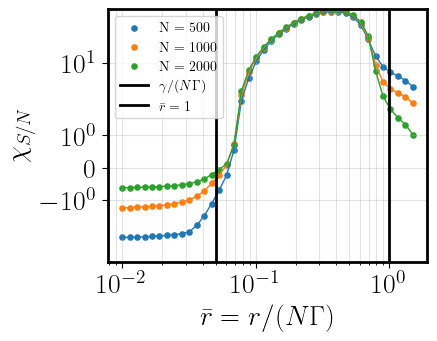

In [216]:
figure(figsize=latex_plot_setup(ratio = 0.8, scale = 2.0))

for N in Ns
    tmp = res_by_N[N]
    x = [q.rbar for q in tmp]
    y = [q.χS for q in tmp]

    scatter(x, y, label = "N = $N", s = 14)
    plot(x, y, linewidth = 1.0)
end

xscale("log")
yscale("symlog")

axvline(0.05, color = "k", linestyle = "solid", linewidth = 2.0, label = L"\gamma/(N\Gamma)")
axvline(1.0, color = "k", linestyle = "solid", linewidth = 2.0, label = L"\bar r = 1")

grid(true, which = "both", alpha = 0.35)
xlabel(L"\bar r = r/(N\Gamma)")
ylabel(L"\chi_{S/N}")
legend(fontsize = 10)
tight_layout()
savefig("susceptibility_scan_for_N.pdf", bbox_inches = "tight")

In [217]:
using KrylovKit
rng = Xoshiro(1234)

for N in [1000]#, 2000, 50000]
    Jmax = N ÷ 2

    g = 37.0
    κ = 9.4e5
    Γ = g^2 / κ
    rbar = 0.5
    r = rbar * N * Γ
    γ = 0.01

    pop_model = PopulationModel(N, Jmax, Γ, 0.0, γ, r, 0.0)
    obsI(S, M, model) = S^2 - M^2

    t_ss, τ_auto = estimate_steady_state_time(pop_model, obsI; N_traj = 100, Δt = Δt_N(N) / Γ, reltol = 1e-2)
    S_samples_raw, M_samples_raw = get_stationary_population_samples_ergodic(pop_model,20_000;t_ss = t_ss,t_sample = 3t_ss,rng = rng)

    params = Dict(
        "global_decay" => pop_model.global_decay,
        "global_pump" => pop_model.global_pump,
        "local_pump" => pop_model.local_pump,
        "local_decay" => pop_model.local_decay,
        "local_dephasing" => pop_model.local_dephasing,
    )

    Ω = build_basis_naive(N, S_samples_raw, M_samples_raw, 20)
    basisΩ, idxΩ, RΩ, leakage = set_up_rate_matrix_on_basis(Ω, params, pop_model.Jmax; close_boundary = true)
    p0 = population_from_samples(basisΩ, idxΩ, S_samples_raw, M_samples_raw)
    p_ss = steady_by_implicit_euler(RΩ, p0; dt=1e3/Γ, nsteps=5)

    basisΩc, idxΩc, Rcoh, leakage_c = set_up_coherence_rate_matrix_on_basis(basisΩ, params, pop_model.Jmax; close_boundary = true)
    #vals_pop, _, info = eigsolve(RΩ, 8, :LR; krylovdim = 30)
    vals_coh, _, info = eigsolve(Rcoh, 8, :LR; krylovdim = 20)
    @show vals_coh
end

vals_coh = ComplexF64[-0.0010193194902150108 + 0.0im, -0.38906646729820227 + 0.6398117988026859im, -0.38906646729820227 - 0.6398117988026859im, -0.7171815004847327 + 0.0im, -0.720153534538575 + 1.2681860797820776im, -0.720153534538575 - 1.2681860797820776im, -1.1222374039055576 + 1.894519984864639im, -1.1222374039055576 - 1.894519984864639im]


 15.244776 seconds (32.08 k allocations: 2.244 MiB)
N = 2000
I_LHS / N = 245278.2348597357
I_RHS / N = 243709.09803776554
I_comm / N = 1569.1368219701649


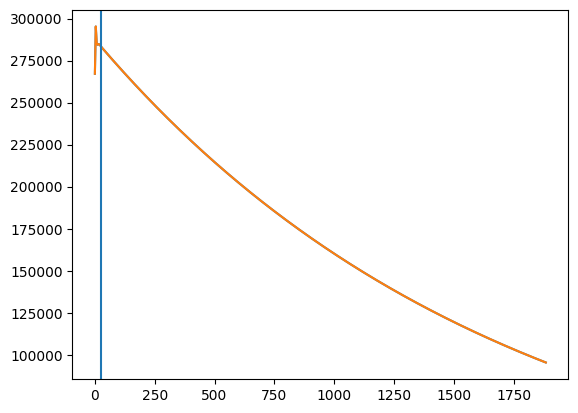

In [98]:

N = 2000
g = 37.0
kappa = 9.4e5
Γ = g^2 / kappa
r = 0.2 * N * Γ
γ = 0.01
s_fac = 0.4

pop_model = PopulationModel(N, Jmax, Γ, 0.0, γ, r, 0.0)

obsI(S, M, model) = S^2 - M^2    

t_ss, τ_auto = estimate_steady_state_time(pop_model, obsI; N_traj = 500, Δt = Δt_N(N) / Γ, reltol = 1e-3)
#S_samples, M_samples = get_stationary_population_samples_ergodic(pop_model, 50000; t_ss = 2*t_ss, t_sample = t_ss * 10.0)
coh_model = CoherenceModel(pop_model)
_, C_lhs, stats_lhs = simulate_coherence_correlator_from_samples_qs(S_samples, M_samples, coh_model; τ_max = 30*t_ss, side = :LHS, t_mix = t_ss * s_fac, n_grid = 500, tail_mode = :deterministic)
τ_grid, C_rhs,  stats_rhs = @time simulate_coherence_correlator_from_samples_qs(S_samples, M_samples, coh_model; τ_max = 30*t_ss, side = :RHS, t_mix = t_ss * s_fac, n_grid = 500, tail_mode = :deterministic)
plot(τ_grid, real.(C_lhs))
plot(τ_grid, real.(C_lhs))
axvline(s_fac * t_ss)

I_LHS = qs_integral(τ_grid, C_lhs, stats_lhs, t_ss * s_fac)
I_RHS = qs_integral(τ_grid, C_rhs, stats_rhs, t_ss * s_fac)

I_comm = I_LHS - I_RHS
@show N I_LHS/N I_RHS/N I_comm/N
println("======")
flush(stdout)


In [5]:
include("TavisCummingsModel.jl")

without_drives (generic function with 1 method)

In [6]:

g = 1.0
κ = 20.0
Γ = 4 * g ^ 2 / κ
p = TCParams(N = 16, γ = 0.01 * Γ, r = 2.0 * Γ, g = g, κ = κ, n_phot = 2, Ωspin = 1e-3, Ωcav = 0.0)
tspan = range(0.0, 50.0, 1000)

sum_space, bcav, ψ0, H, J, rates, Sp, Sm, Sz = TavisCummingsModel(p)
tout, ρtot = timeevolution.master(tspan, ψ0, H, J; rates = rates)

Sminus_exact = expect(Sm, ρtot)

plot(tout, imag.(Sminus_exact) / p.Ωspin, label = "exact", linestyle = "dashed")

LoadError: InterruptException:

I_comm = 4.4192941354835895
I_LHS = 51.611906087377626
I_RHS = 47.19261195189404


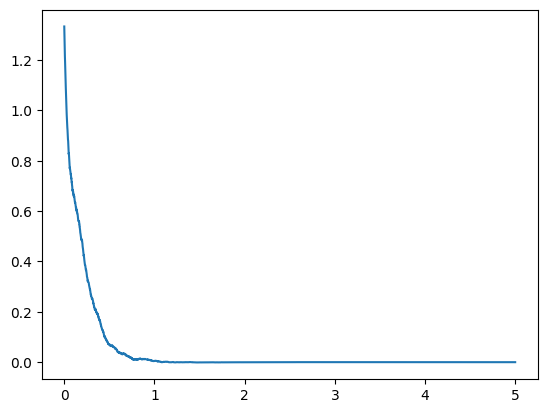

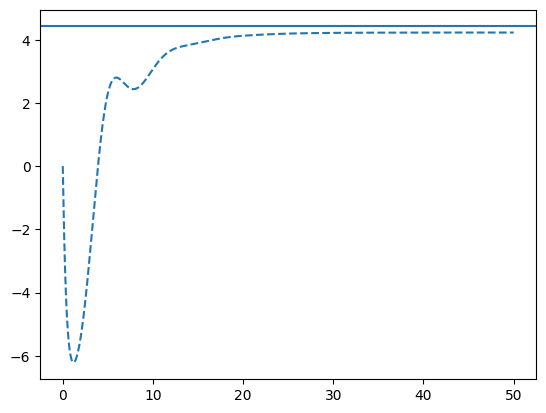

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x17de46a50>

In [ ]:
N = 16

g = 1.0
κ = 20.0
Γ = 4 * g ^ 2 / κ
r = 2.0 * Γ
γ = 0.01* Γ

pop_model = PopulationModel(N, N ÷ 2, Γ, 0.0, 0.01, r, 0.0)

obsI(S, M, model) = S^2 - M^2
t_ss, τ_auto = estimate_steady_state_time(pop_model, obsI; N_traj = 1000, Δt = Δt_N(N) / Γ, reltol = 1e-3)
S_samples, M_samples = get_stationary_population_samples_ergodic(pop_model, 200000; t_ss = 2*t_ss, t_sample = t_ss * 5)

coh_model = CoherenceModel(pop_model)
_, C_lhs = simulate_coherence_correlator_from_samples_LHS(S_samples, M_samples, coh_model; τ_max = 5*t_ss, n_grid = 5000)
τ_grid, C_rhs = simulate_coherence_correlator_from_samples_RHS(S_samples, M_samples, coh_model; τ_max = 5*t_ss, n_grid = 5000)
plot(τ_grid / t_ss, C_lhs - C_rhs)

I_LHS = trapezoid(C_lhs, τ_grid)
I_RHS = trapezoid(C_rhs, τ_grid)

I_comm = I_LHS - I_RHS
@show I_comm I_LHS I_RHS
figure()
axhline(I_comm)
plot(tout, imag.(Sminus_exact) / p.Ωspin, label = "exact", linestyle = "dashed")

In [ ]:
using Optim

f(x,y) = x^5+x^2*y^2-y^6

function plot_me(y)
    x0 = [0.1]
    res = optimize((x) -> abs(f(x,y)), x0)
    return res.minimizer
end

results = [plot_me(y) for y in range(-1.0, 1.0, 2000)]
scatter(map(x->x[1], results), last.(results))

LoadError: MethodError: [0mCannot `convert` an object of type [92mVector{Float64}[39m[0m to an object of type [91mFloat64[39m
The function `convert` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  convert(::Type{T}, [91m::VectorInterface.Zero[39m) where T<:Number
[0m[90m   @[39m [36mVectorInterface[39m [90m~/.julia/packages/VectorInterface/J6qCR/src/[39m[90m[4monezero.jl:83[24m[39m
[0m  convert(::Type{T}, [91m::CartesianIndex{1}[39m) where T<:Number
[0m[90m   @[39m [90mBase[39m [90m[4mmultidimensional.jl:139[24m[39m
[0m  convert(::Type{T}, [91m::VectorInterface.One[39m) where T<:Number
[0m[90m   @[39m [36mVectorInterface[39m [90m~/.julia/packages/VectorInterface/J6qCR/src/[39m[90m[4monezero.jl:81[24m[39m
[0m  ...
